In [1]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load Data

In [15]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])   
])

In [16]:
dataset_path = "./dataset"
dataset = datasets.ImageFolder(root=dataset_path,transform=image_transforms)

In [17]:
len(dataset)

2300

In [18]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [14]:
num_classes = len(dataset.classes)
num_classes

6

In [25]:
train_size = int(0.75 * len(dataset))
val_size = len(dataset)-train_size
train_size,val_size


(1725, 575)

In [26]:
from torch.utils.data import random_split
train_dataset, val_dataset = random_split(dataset,[train_size,val_size])

In [27]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.2739873].


torch.Size([32, 3, 224, 224])
torch.Size([32])


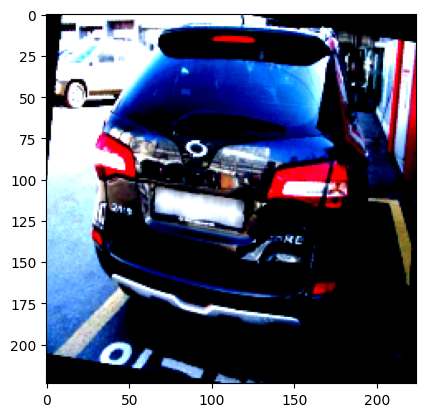

In [30]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

labels[0]

images[0].shape

images[0].permute(1,2,0).shape

plt.imshow(images[0].permute(1,2,0))
plt.show()

## Model 1 : CNN

In [32]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), # (16, 224, 224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16, 112, 112),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28),
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.network(x)
        return x

In [34]:
# Instantiate the model, loss function, and optimizer
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [35]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():.2f}")

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

        print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")

    end = time.time()
    print(f"Execution time: {end - start} seconds")

    return all_labels, all_predictions

In [37]:
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=5)

Batch: 10, Epoch: 1, Loss: 1.74
Batch: 20, Epoch: 1, Loss: 1.30
Batch: 30, Epoch: 1, Loss: 1.31
Batch: 40, Epoch: 1, Loss: 1.04
Batch: 50, Epoch: 1, Loss: 1.27
Epoch [1/5], Avg Loss: 1.3554
*** Validation Accuracy: 48.35% ***
Batch: 10, Epoch: 2, Loss: 1.13
Batch: 20, Epoch: 2, Loss: 1.22
Batch: 30, Epoch: 2, Loss: 1.01
Batch: 40, Epoch: 2, Loss: 0.96
Batch: 50, Epoch: 2, Loss: 0.98
Epoch [2/5], Avg Loss: 1.1057
*** Validation Accuracy: 52.87% ***
Batch: 10, Epoch: 3, Loss: 0.87
Batch: 20, Epoch: 3, Loss: 1.22
Batch: 30, Epoch: 3, Loss: 1.03
Batch: 40, Epoch: 3, Loss: 0.89
Batch: 50, Epoch: 3, Loss: 0.88
Epoch [3/5], Avg Loss: 1.0019
*** Validation Accuracy: 52.87% ***
Batch: 10, Epoch: 4, Loss: 0.98
Batch: 20, Epoch: 4, Loss: 0.81
Batch: 30, Epoch: 4, Loss: 0.94
Batch: 40, Epoch: 4, Loss: 0.91
Batch: 50, Epoch: 4, Loss: 0.80
Epoch [4/5], Avg Loss: 0.9420
*** Validation Accuracy: 54.26% ***
Batch: 10, Epoch: 5, Loss: 1.23
Batch: 20, Epoch: 5, Loss: 0.80
Batch: 30, Epoch: 5, Loss: 1.10
